# Matplotlib with pandas - real data

In [2]:
import pandas as pd

df = pd.read_csv("retail_store_sales.csv")

print(df.head())

  Transaction ID Customer ID       Category          Item  Price Per Unit  \
0    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1    TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2    TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3    TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4    TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   

   Quantity  Total Spent  Payment Method Location Transaction Date  \
0      10.0        185.0  Digital Wallet   Online       2024-04-08   
1       9.0        261.0  Digital Wallet   Online       2023-07-23   
2       2.0         43.0     Credit Card   Online       2022-10-05   
3       9.0        247.5     Credit Card   Online       2022-05-07   
4       7.0         87.5  Digital Wallet   Online       2022-10-02   

  Discount Applied  
0             True  
1             True  
2            False  
3              NaN  
4          

# Remove missing values


In [3]:
df = df.dropna()

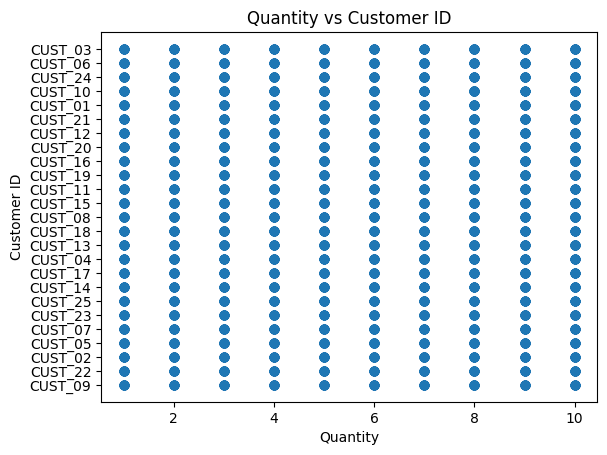

In [4]:
import matplotlib.pyplot as plt

plt.scatter(df["Quantity"], df["Customer ID"])
plt.xlabel("Quantity")
plt.ylabel("Customer ID")
plt.title("Quantity vs Customer ID")
plt.show()

# Convert date column to datetime


In [5]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# 1. SALES PERFORMANCE

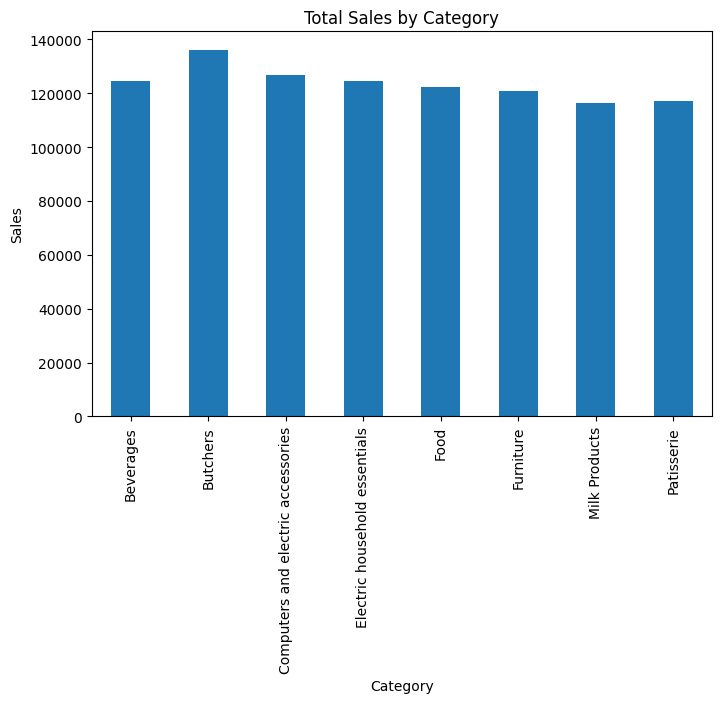

In [6]:

# Total sales by category
category_sales = df.groupby('Category')['Total Spent'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

# Most sold items


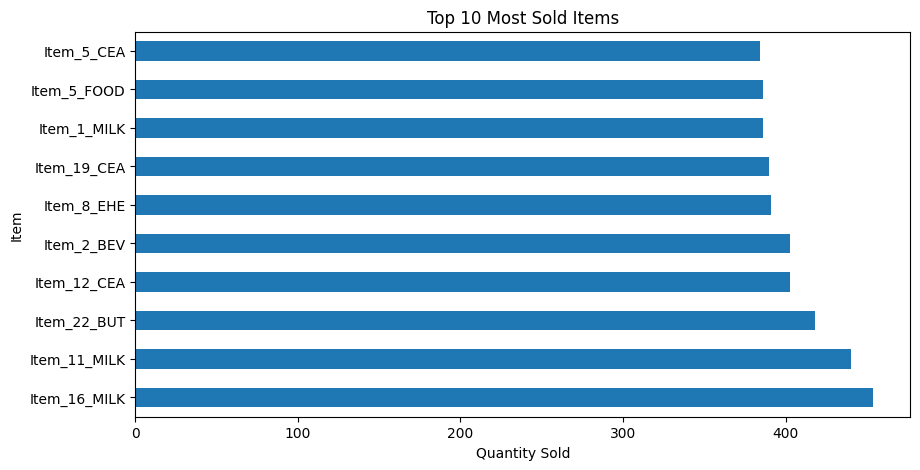

In [9]:
item_quantity = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
item_quantity.plot(kind='barh')
plt.title("Top 10 Most Sold Items")
plt.xlabel("Quantity Sold")
plt.show()

# Online vs In-store sales


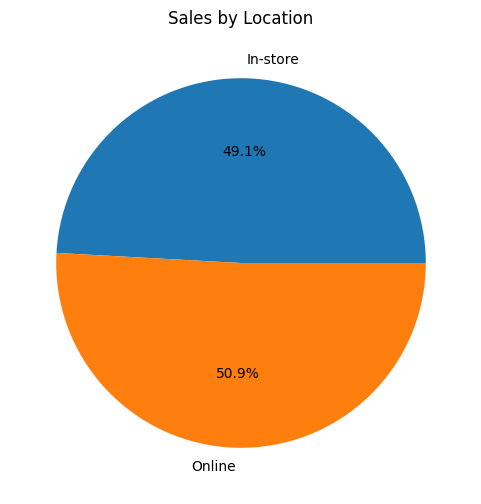

In [12]:
location_sales = df.groupby('Location')['Total Spent'].sum()

plt.figure(figsize=(6,6))
location_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Location")
plt.show()

# 2. CUSTOMER BUYING BEHAVIOR

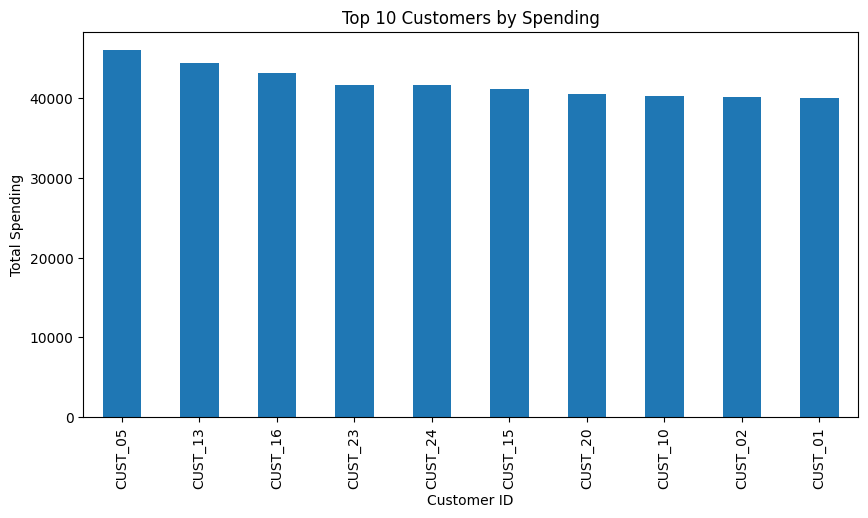

In [13]:


# Top customers
top_customers = df.groupby('Customer ID')['Total Spent'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")
plt.show()

In [ ]:
# Average quantity purchased
avg_quantity = df['Quantity'].mean()
print("Average Quantity Purchased:", avg_quantity)

Average Quantity Purchased: 5.55732946298984


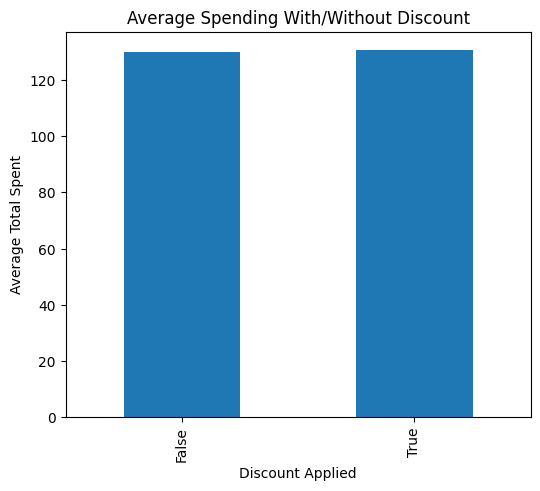

In [15]:
# Discount impact
discount_sales = df.groupby('Discount Applied')['Total Spent'].mean()

plt.figure(figsize=(6,5))
discount_sales.plot(kind='bar')
plt.title("Average Spending With/Without Discount")
plt.ylabel("Average Total Spent")
plt.show()

# 3. PAYMENT METHOD ANALYSIS

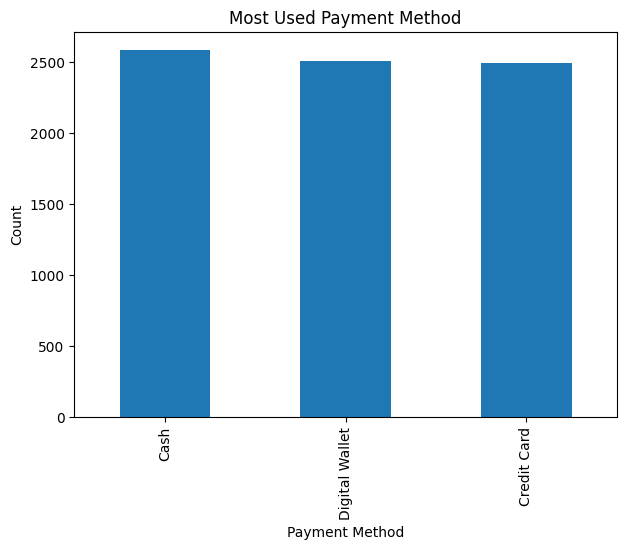

In [17]:
# Most used payment method
payment_count = df['Payment Method'].value_counts()

plt.figure(figsize=(7,5))
payment_count.plot(kind='bar')
plt.title("Most Used Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.show()

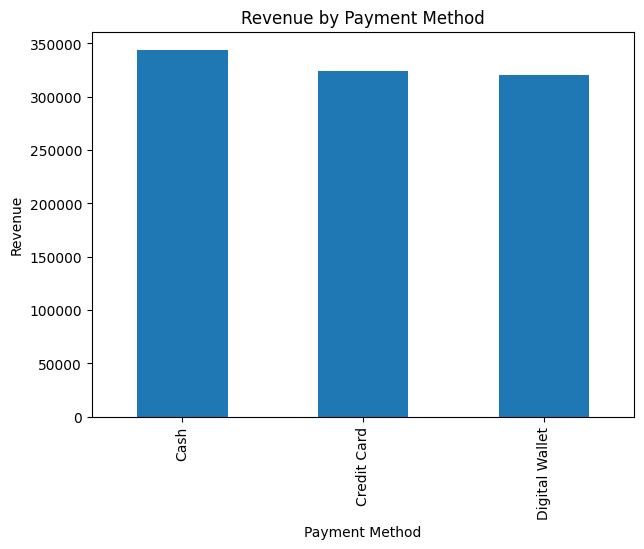

In [19]:
# Highest revenue payment method
payment_revenue = df.groupby('Payment Method')['Total Spent'].sum()

plt.figure(figsize=(7,5))
payment_revenue.plot(kind='bar')
plt.title("Revenue by Payment Method")
plt.ylabel("Revenue")
plt.show()

# 4. DISCOUNT ANALYSIS

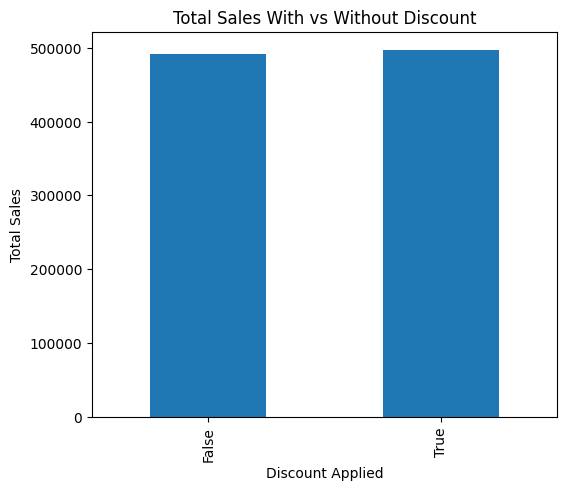

In [20]:


# Compare spending with/without discount
discount_compare = df.groupby('Discount Applied')['Total Spent'].sum()

plt.figure(figsize=(6,5))
discount_compare.plot(kind='bar')
plt.title("Total Sales With vs Without Discount")
plt.ylabel("Total Sales")
plt.show()

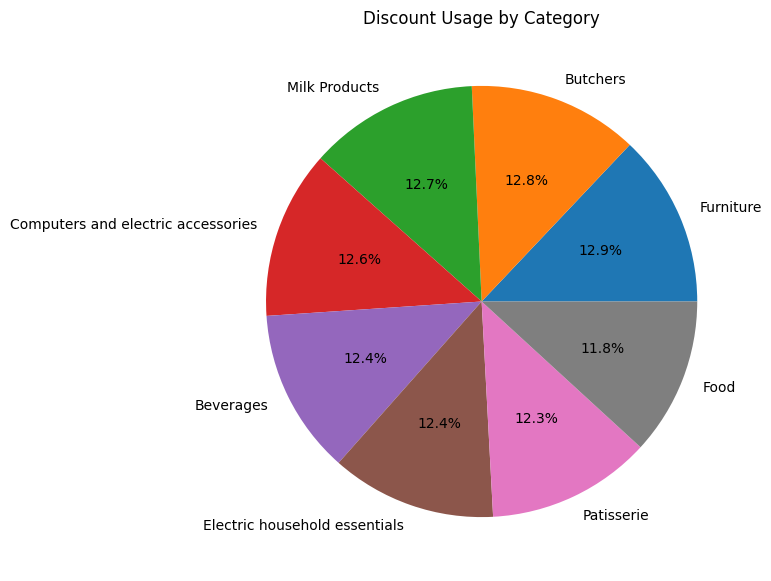

In [21]:
# Categories using discounts most
discount_category = df[df['Discount Applied'] == True]['Category'].value_counts()

plt.figure(figsize=(7,7))
discount_category.plot(kind='pie', autopct='%1.1f%%')
plt.title("Discount Usage by Category")
plt.ylabel("")
plt.show()

<Figure size 700x500 with 0 Axes>

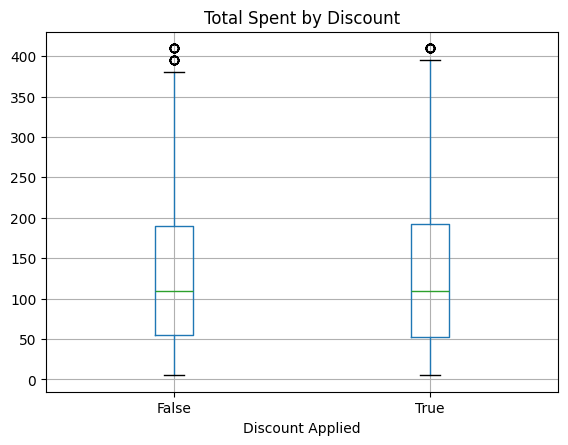

In [22]:
# Boxplot
plt.figure(figsize=(7,5))
df.boxplot(column='Total Spent', by='Discount Applied')
plt.title("Total Spent by Discount")
plt.suptitle("")
plt.show()

# 5. TIME-BASED ANALYSIS

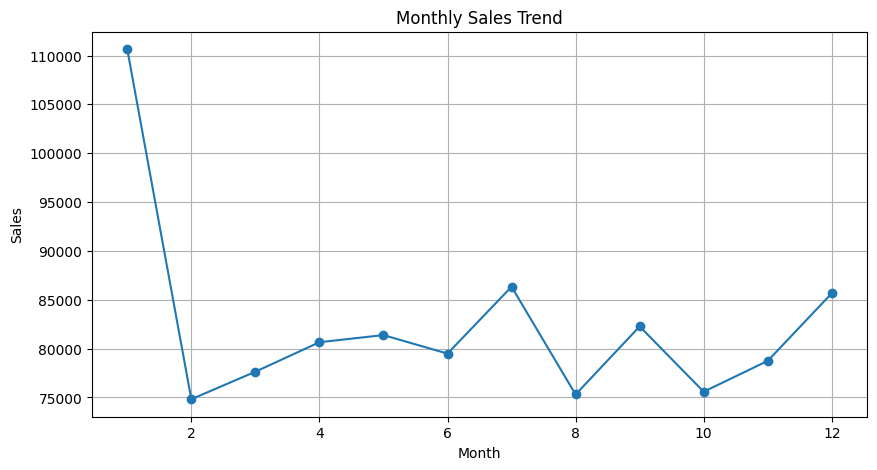

In [24]:
# Sales by month
df['Month'] = df['Transaction Date'].dt.month

monthly_sales = df.groupby('Month')['Total Spent'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

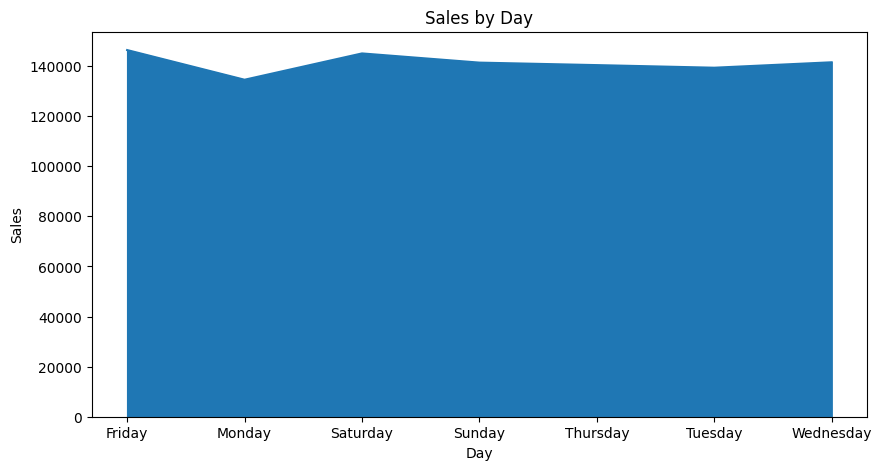

In [25]:
# Sales by day
df['Day'] = df['Transaction Date'].dt.day_name()

daily_sales = df.groupby('Day')['Total Spent'].sum()

plt.figure(figsize=(10,5))
daily_sales.plot(kind='area')
plt.title("Sales by Day")
plt.ylabel("Sales")
plt.show()